In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

In [2]:
# 1. Load the data with selected features
df = pd.read_csv('../data/selected_features_heart_disease.csv')
X = df.drop('target', axis=1)
y = df['target']

In [3]:
# 2. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# 3. Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42) # probability=True for ROC curve
}


In [5]:
# 4. Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    results[name] = {'accuracy': accuracy, 'report': report, 'model': model}
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(report)

--- Logistic Regression ---
Accuracy: 0.8689
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

--- Decision Tree ---
Accuracy: 0.7869
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        33
           1       0.74      0.82      0.78        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61

--- Random Forest ---
Accuracy: 0.9180
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        33
           1       0.90      0.93      0.91        28

    accuracy                           0.92        61
   ma

In [6]:
with open('../results/model_performance.txt', 'w') as f:
    for name, result in results.items():
        y_pred = result['model'].predict(X_test)
        report = classification_report(y_test, y_pred)
        f.write(f"--- Performance for {name} ---\n")
        f.write(report)
        f.write("\n\n")

print("Model performance reports saved to results/model_performance.txt")

Model performance reports saved to results/model_performance.txt


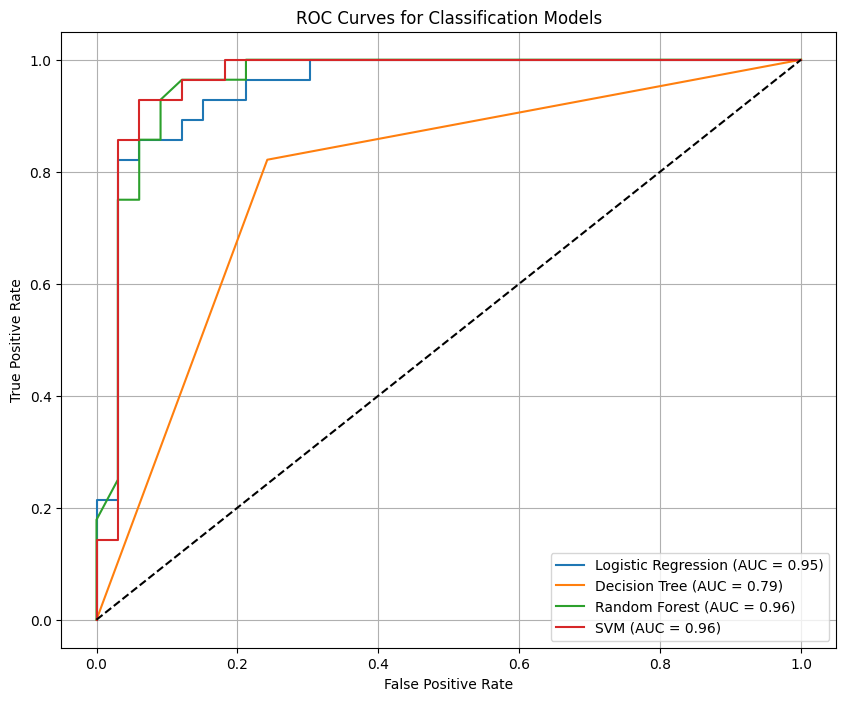

In [7]:
# 5. Plot ROC Curves
plt.figure(figsize=(10, 8))
for name, result in results.items():
    model = result['model']
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classification Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()